In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
os.environ['CUDA_VISIBLE_DEVICES'] = '0'
import torch
from diffusers import FluxPriorReduxPipeline, FluxPipeline, FluxControlNetPipeline, FluxControlNetModel
from diffusers.models import FluxMultiControlNetModel
from PIL import Image
import random
import json
import cv2
import numpy as np
from matplotlib import pyplot as plt
from torch.nn import functional as F
from detector.canny_detect import CannyDetect
from utils import get_mask_ori, get_mask_ref, get_min_bounding_box

/amax/hchuz/miniconda3/envs/py310/lib/python3.10/site-packages/controlnet_aux/mediapipe_face/mediapipe_face_common.py:7: UserWarning: The module 'mediapipe' is not installed. The package will have limited functionality. Please install it using the command: pip install 'mediapipe'
  warnings.warn(


In [3]:
# paras
device = 'cuda'
model_id = "black-forest-labs/FLUX.1-dev"
#model_id = 'black-forest-labs/FLUX.1-schnell'
controlnet_model_union = '/amax/hchuz/hfd_models/FLUX.1-dev-ControlNet-Union-Pro'
control = True
offload = False

In [4]:
pipe_prior_redux = FluxPriorReduxPipeline.from_pretrained("black-forest-labs/FLUX.1-Redux-dev", torch_dtype=torch.bfloat16).to(device)
cannydetect = CannyDetect()

Loading pipeline components...:   0%|          | 0/3 [00:00<?, ?it/s]

In [5]:
# no_control
if not control:
    pipe = FluxPipeline.from_pretrained(
        model_id , 
        text_encoder=None,
        text_encoder_2=None,
        torch_dtype=torch.bfloat16)
else:
    controlnet_union = FluxControlNetModel.from_pretrained(controlnet_model_union, torch_dtype=torch.bfloat16)
    controlnet = FluxMultiControlNetModel([controlnet_union]) # we always recommend loading via FluxMultiControlNetModel
    pipe = FluxControlNetPipeline.from_pretrained(model_id,         
                                                  text_encoder=None,
                                                  text_encoder_2=None,
                                                  controlnet=controlnet, torch_dtype=torch.bfloat16)
if not offload:
    _ = pipe.to(device)
else:
    pipe.enable_model_cpu_offload()

Loading pipeline components...:   0%|          | 0/5 [00:00<?, ?it/s]

You set `add_prefix_space`. The tokenizer needs to be converted from the slow tokenizers


Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

In [6]:
if 'dev' in model_id:
    kwargs = {
            'guidance_scale':2.5,
            'num_inference_steps':20,
        }
else:
    kwargs={
        'guidance_scale':0,
        'num_inference_steps':4
    }

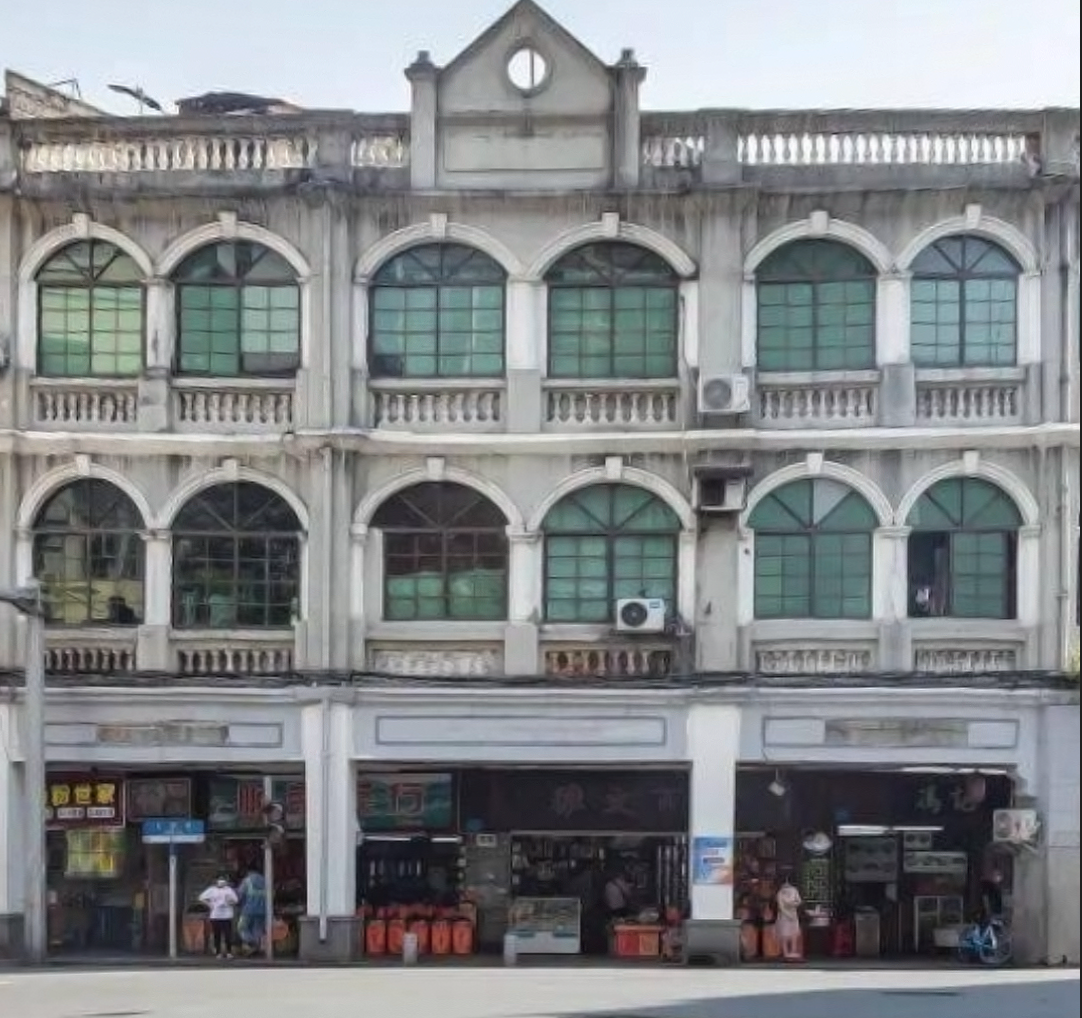

In [7]:
ref_img_path = '/amax/hchuz/architectural_heritage/相似的几个2/Snipaste_2023-03-08_21-09-23.png'
ref_img = Image.open(ref_img_path).convert('RGB')
ref_img

In [8]:
with open(ref_img_path.replace('.png', '.json'), 'r') as f:
    ann = json.load(f)

In [9]:
height = ref_img.height
width = ref_img.width
height_lt = height//16
width_lt = width//16
ori_tokens = height_lt * width_lt
num_ref_imgs = 1
total_tokens = 1241 * num_ref_imgs + ori_tokens
attention_mask = torch.ones(1, total_tokens, total_tokens, dtype=torch.bool, device='cuda')
itr = attention_mask[:, 1241*num_ref_imgs:, 512:1241]

# attention_mask[:, 1241*num_ref_imgs:, 1241:1241+1241] = 0
# itr_2 = attention_mask[:, 1241*num_ref_imgs:, 1241+512:1241+1241]

def mask_focus(it, mask_ori, mask_ref):
    it[:, mask_ori.flatten().bool()] = False
    it[:,(torch.outer(mask_ori.flatten(), mask_ref.flatten())).bool()] = True

# focus on origin
for shape in ann['shapes']:
    mask_ori = get_mask_ori(shape['points'], height, width, height_lt, width_lt)
    mask_ref = get_mask_ref(mask_ori)
    # mask_ori = get_min_bounding_box(mask_ori)
    # mask_ref = get_min_bounding_box(mask_ref)
    mask_focus(itr, mask_ori, mask_ref)


# change focus

# # shop
# mask1_ori, mask1_ref = get_mask(ann['shapes'][1]['points'], height, width, height_lt, width_lt)
# mask2_ori, mask2_ref = get_mask(ann['shapes'][2]['points'], height, width, height_lt, width_lt)

#mask1_ori, mask1_ref = get_mask(ann['shapes'][0]['points'], height, width, height_lt, width_lt)

# # wall
# mask1_ori = get_mask_ori(ann['shapes'][0]['points'], height, width, height_lt, width_lt)
# for shape in ann['shapes']:
#     if shape['label'] == 'window':
#         mask1_ori_ = get_mask_ori(shape['points'], height, width, height_lt, width_lt)
#         mask1_ori = (mask1_ori.bool() & ~(mask1_ori_.bool())).float()

# mask2_ref = torch.ones(729, dtype=torch.float)
# mask_focus(itr_2, mask1_ori, mask2_ref)

# mask_focus(mask1_ori, mask2_ref)
# mask_focus(mask2_ori, mask1_ref)

In [10]:
if control:
    control_image = cannydetect.polygon2canny_2([sample['points'] for sample in ann['shapes']], height, width)
    kwargs.update({'control_image':[control_image],
                   'control_mode':[0],
                   'controlnet_conditioning_scale':[0.2]})

In [11]:
pipe_prior_output = pipe_prior_redux(ref_img)
# pipe_prior_output_2 = pipe_prior_redux(ref_img_2)
# pipe_prior_output['prompt_embeds'] = torch.cat([pipe_prior_output['prompt_embeds'], pipe_prior_output_2['prompt_embeds']], dim=1)

In [ ]:
seed = random.randint(0,10000)

  0%|          | 0/20 [00:00<?, ?it/s]

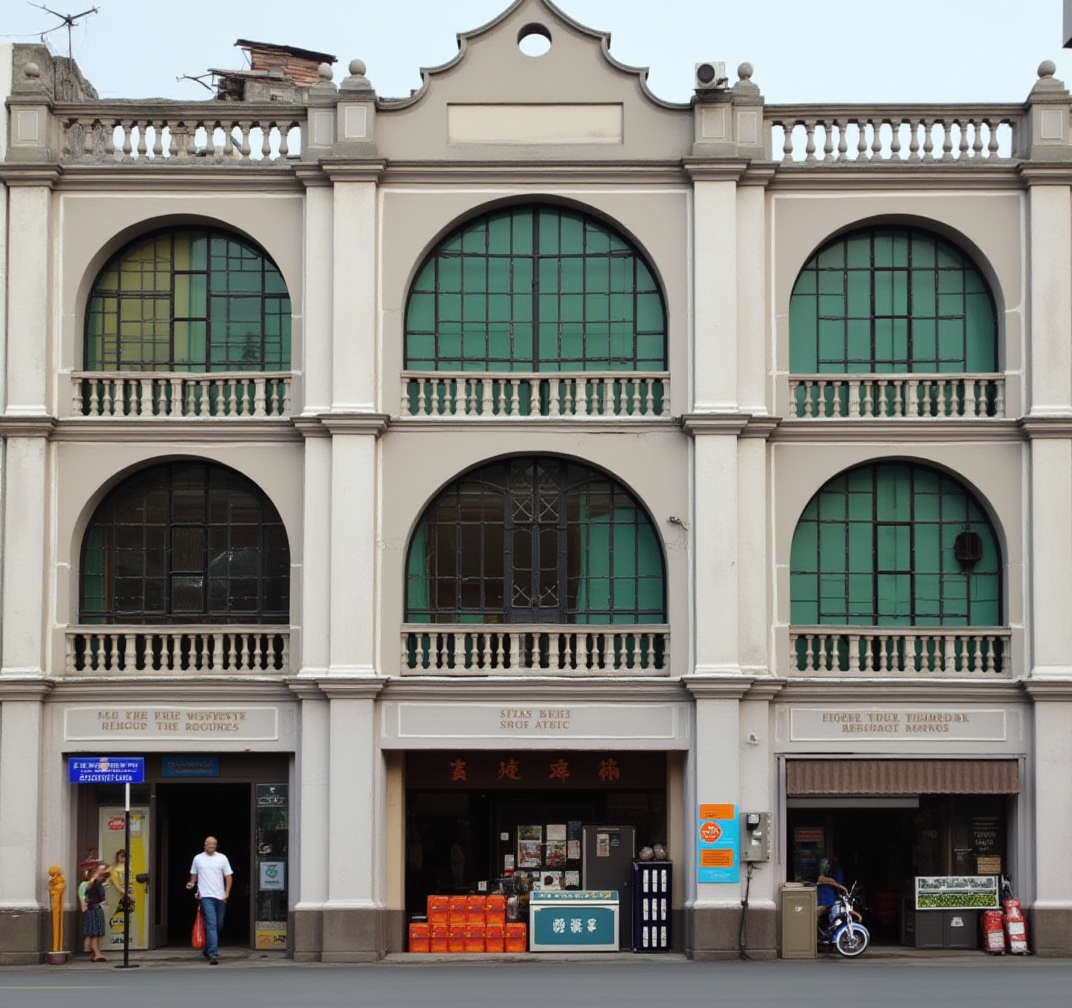

In [14]:
images = pipe(
    **kwargs,
    height = height//16*16,
    width = width//16*16,
    generator=torch.Generator("cpu").manual_seed(seed),
    **pipe_prior_output,
    joint_attention_kwargs = {'attention_mask':attention_mask}
).images
images[0]

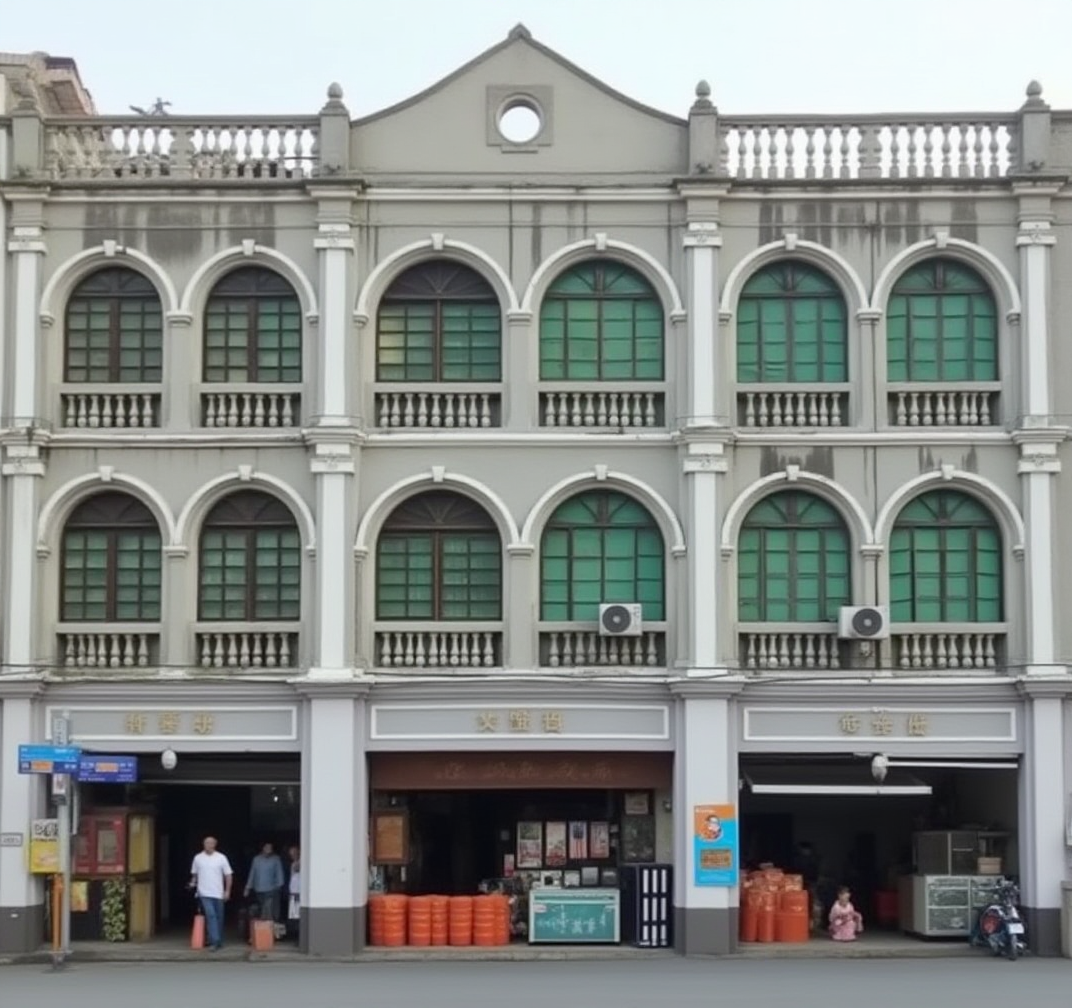

In [13]:
images[0]